In [228]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
from sklearn import linear_model,model_selection
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"  # Embeds full JS for HTML export

In [229]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [230]:
# Analyze the original dataset
df_CellDNA=pd.read_csv("ML_HW_Data_CellDNA.csv",header=None)
print("Shape : ", df_CellDNA.shape)
print('********************************************')
print("checking for null columns :\n ", df_CellDNA.isnull().sum())
print('********************************************')
print("describe: \n ",df_CellDNA.describe())
print('********************************************')

Shape :  (1217, 14)
********************************************
checking for null columns :
  0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64
********************************************
describe: 
                  0            1            2            3            4   \
count  1217.000000  1217.000000  1217.000000  1217.000000  1217.000000   
mean    200.366475   419.476953   211.335155    33.388599     9.376939   
std     135.665649   215.563920   141.592818    19.152143     3.634969   
min      70.000000    28.176471    27.870130    10.282437     3.080963   
25%     107.000000   243.400000    96.200000    18.760441     7.529888   
50%     160.000000   415.360000   183.834286    27.832476     8.463304   
75%     252.000000   611.128440   292.824742    44.462419     9.801152   
max    1089.000000   773.919643   575.340206   155.330123    43.487111   

                5            6            7            

There is no missing data in the original dataset. 
We can proceed with the analysis without needing to handle missing values. 
Keeping only the relevant columns for further analysis.

In [231]:
X_df = df_CellDNA.drop(columns=[13])  # Features DataFrame
X = zscore(X_df, axis=0).values  #  standardized value (zscore per column ) 
Y=np.where(df_CellDNA[13].values==0,0,1)  # Target variable (last column)

In [232]:
# 2. Building Model
# Split dataset into training and testing portion
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X,Y,test_size = 0.20 ,random_state = 1234)

In [233]:
mdl=linear_model.LogisticRegression(C=1,penalty='l1',solver="liblinear",max_iter=1000)
mdl.fit(X_train, Y_train)
print(mdl.intercept_ ) # Intercept of the model/base probability
print(mdl.coef_ ) # Coefficients of the model/feature importance
print(mdl.predict_proba(X)[:, 1]) # Predicted probabilities for the positive class

[-4.19616305]
[[ 0.          0.09328269  0.          3.04549502 -3.88133511  0.05474671
  -0.26471255  0.          0.66975444  0.49532565 -0.25156728  0.03621828
   0.        ]]
[0.05824374 0.00650563 0.0153767  ... 0.01348969 0.58236217 0.00078822]


Confusion Matrix:
 [[198  11]
 [ 10  25]]


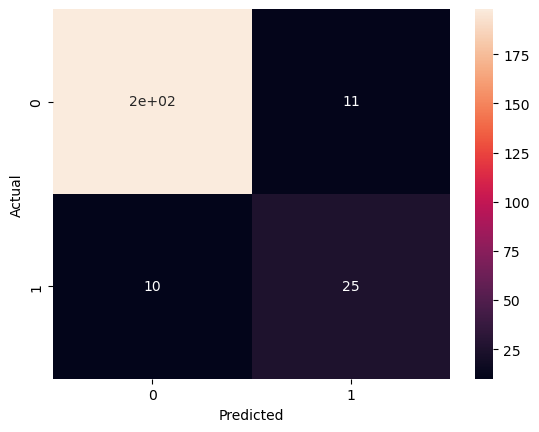

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       209
           1       0.69      0.71      0.70        35

    accuracy                           0.91       244
   macro avg       0.82      0.83      0.83       244
weighted avg       0.91      0.91      0.91       244



In [234]:
Y_pred = mdl.predict(X_test)  # Predicted class labels for the test set

print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred))

confusion_matrix = pd.crosstab(Y_test, Y_pred,rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(confusion_matrix, annot=True)
plt.show()


Stats = classification_report(Y_test, Y_pred)
print(Stats)

In [235]:
# Remove outliers in y (Systolic) first
Q1 = df_patients['Systolic'].quantile(0.25)
Q3 = df_patients['Systolic'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep only non-outlier rows (both X and y)
mask = (df_patients['Systolic'] >= lower_bound) & (df_patients['Systolic'] <= upper_bound)
df_no_outliers = df_patients[mask].copy()

print("Number of outliers removed:", df_patients.shape[0] - df_no_outliers.shape[0])
print("New shape after removing outliers:", df_no_outliers.shape)


NameError: name 'df_patients' is not defined

In [ ]:
X_original= df_no_outliers[["Age","Gender","Height","Weight","Smoker","Location","SelfAssessedHealthStatus"]].copy()
Y_original = df_no_outliers["Systolic"].copy()

In [ ]:
# standardize numerical data
num_cols = ["Age", "Height", "Weight"]
scaler = StandardScaler()
X_scaled_nums = scaler.fit_transform(X_original[num_cols])
X_original[num_cols] = pd.DataFrame(X_scaled_nums, columns=num_cols, index=X_original.index)
print(X_original.head())
print("*********************************************")
#store the mean and variance for later use
X_num_mean = scaler.mean_
X_num_var = scaler.var_
X_num_std=scaler.scale_
print('test mean: ',X_num_mean)
print('test var: ',X_num_var)
print('test standard deviation: ',X_num_std)

        Age    Gender    Height    Weight  Smoker  \
0 -0.039001    'Male'  1.392506  0.832128       1   
1  0.657450    'Male'  0.683851  0.340416       0   
2 -0.039001  'Female' -1.087784 -0.869952       0   
3  0.239579  'Female' -0.024803 -0.794304       0   
4  1.493193  'Female' -1.087784 -1.323841       0   

                      Location SelfAssessedHealthStatus  
0    'County General Hospital'              'Excellent'  
1                'VA Hospital'                   'Fair'  
2  'St. Mary's Medical Center'                   'Good'  
3                'VA Hospital'                   'Fair'  
4    'County General Hospital'                   'Good'  
*********************************************
test mean:  [ 38.28  67.07 154.  ]
test var:  [ 51.5416   7.9651 698.98  ]
test standard deviation:  [ 7.17924787  2.82225087 26.4382299 ]


In [ ]:
#create dummy vars for categorical data
X = pd.get_dummies(
    X_original,
    columns=["Gender", "Location", "SelfAssessedHealthStatus"],
    drop_first=True
)
print(X.head())


        Age    Height    Weight  Smoker  Gender_'Male'  \
0 -0.039001  1.392506  0.832128       1           True   
1  0.657450  0.683851  0.340416       0           True   
2 -0.039001 -1.087784 -0.869952       0          False   
3  0.239579 -0.024803 -0.794304       0          False   
4  1.493193 -1.087784 -1.323841       0          False   

   Location_'St. Mary's Medical Center'  Location_'VA Hospital'  \
0                                 False                   False   
1                                 False                    True   
2                                  True                   False   
3                                 False                    True   
4                                 False                   False   

   SelfAssessedHealthStatus_'Fair'  SelfAssessedHealthStatus_'Good'  \
0                            False                            False   
1                             True                            False   
2                            False 

In [ ]:
#creating linear regression model
reg = LinearRegression()
reg.fit(X, Y_original)

print('Coefficients: \n', reg.coef_ ) 


Coefficients: 
 [ 0.57620401  1.32538712 -0.35475725  9.67308711 -1.47939073 -0.85650078
 -1.73484051 -2.75096823  0.58637873  0.45934283]


In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg.coef_
}).sort_values('Coefficient', ascending=False)
print(f'\nIntercept: {reg.intercept_:.3f}')
print("*********************************************")
print('Coefficients for all features: \n')
print(coef_df)
print("*********************************************")



Intercept: 121.161
*********************************************
Coefficients for all features: 

                                Feature  Coefficient
3                                Smoker     9.673087
1                                Height     1.325387
8       SelfAssessedHealthStatus_'Good'     0.586379
0                                   Age     0.576204
9       SelfAssessedHealthStatus_'Poor'     0.459343
2                                Weight    -0.354757
5  Location_'St. Mary's Medical Center'    -0.856501
4                         Gender_'Male'    -1.479391
6                Location_'VA Hospital'    -1.734841
7       SelfAssessedHealthStatus_'Fair'    -2.750968
*********************************************


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y_original, test_size = .2, random_state = 1234) 

In [ ]:
model = LassoLarsCV(cv=10,normalize=False)
model.fit(x_train, y_train)


coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(f'\nIntercept: {model.intercept_:.3f}')
print("*********************************************")
print('Coefficients for all features with LassoLarsCV model \n')
print(coef_df)
print("*********************************************")
print('Lasso Scores:')
print('Train ', model.score(x_train, y_train.values.ravel()))
print('Test', model.score(x_test, y_test))
print("*********************************************")
print("Best alpha using built-in LassoLarsCV: %f" % model.alpha_)



Intercept: 119.832
*********************************************
Coefficients for all features with LassoLarsCV model 

                                Feature  Coefficient
3                                Smoker     8.352177
1                                Height     0.329577
0                                   Age     0.108403
2                                Weight     0.000000
4                         Gender_'Male'     0.000000
5  Location_'St. Mary's Medical Center'     0.000000
6                Location_'VA Hospital'     0.000000
7       SelfAssessedHealthStatus_'Fair'     0.000000
8       SelfAssessedHealthStatus_'Good'     0.000000
9       SelfAssessedHealthStatus_'Poor'     0.000000
*********************************************
Lasso Scores:
Train  0.528836532311346
Test 0.3538214020619953
*********************************************
Best alpha using built-in LassoLarsCV: 0.421897


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:116: FutureWarning:

'normalize' was deprecated in version 1.2 and will be removed in 1.4. Please leave the normalize parameter to its default value to silence this warning. The default behavior of this estimator is to not do any normalization. If normalization is needed please use sklearn.preprocessing.StandardScaler instead.



In [ ]:
print("Features with non-zero coefficient values after LassoLar CV:", coef_df[coef_df["Coefficient"] > 0])


Features with non-zero coefficient values after LassoLar CV:   Feature  Coefficient
3  Smoker     8.352177
1  Height     0.329577
0     Age     0.108403


In [ ]:
print("Coefficients over different lambda values: ")
m_log_alphas_lars = -np.log10(model.alphas_)
for i, alpha in enumerate(m_log_alphas_lars):
    print(f"α={alpha:.6f}: {model.coef_path_.T[i, :].round(4)}")

Coefficients over different lambda values: 
α=-0.358649: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
α=0.002741: [0.     0.     0.     5.8805 0.     0.     0.     0.     0.     0.    ]
α=0.269197: [0.   0.27 0.   7.85 0.   0.   0.   0.   0.   0.  ]
α=0.374793: [0.1084 0.3296 0.     8.3522 0.     0.     0.     0.     0.     0.    ]


In [ ]:
# plot coefficient progression lasso lars, plotly library
fig = go.Figure()
feature_names = x_train.columns.tolist() if hasattr(x_train, 'columns') else [f'Feat_{i}' for i in range(x_train.shape[1])]
for i in range(len(model.coef_path_.T)):
  fig.add_trace(go.Scatter(x=m_log_alphas_lars, y=model.coef_path_.T[:, i], name=feature_names[i], mode='lines'))
fig.add_vline(
    x=-np.log10(model.alpha_),
    line_width=2,
    line_dash="dash",
    line_color="black",
    annotation_text="alpha CV",
    annotation_position="top right"
)
fig.update_layout(xaxis_title="-log(alpha)", yaxis_title="Regression Coefficients", title="Regression Coefficients Progression for Lasso Using LARS Alg")
fig.show()

/var/folders/8_/hl_k07fn50q85s8d3_rpbch80000gn/T/ipykernel_38829/2194232607.py:2: RuntimeWarning:

divide by zero encountered in log10



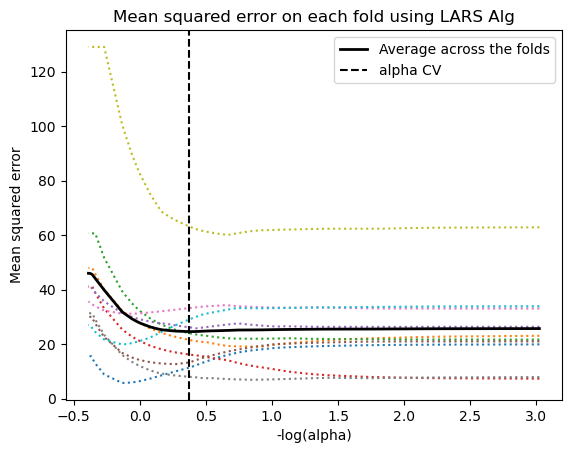

In [ ]:
# plot MSE for each fold lasso lars
m_log_alphascv_lars = -np.log10(model.cv_alphas_)
plt.figure()
plt.plot(m_log_alphascv_lars, model.mse_path_, ':')
plt.plot(m_log_alphascv_lars, model.mse_path_.mean(axis=-1), 'k', label='Average across the folds', linewidth=2)
plt.axvline(-np.log10(model.alpha_), linestyle='--', color='k', label='alpha CV')
plt.legend()
plt.xlabel('-log(alpha)')
plt.ylabel('Mean squared error')
plt.title('Mean squared error on each fold using LARS Alg')
plt.show()